In [1]:
import sys
sys.path.append('..')

### Investigating `minor_ratio` in Waterbirds module

In [2]:
from smoothAttributionPrior.module.utils.spurious_dataset import SpuriousDataset
import os
import torch
from torch.utils.data import DataLoader
from torchvision import transforms

root = '/media/disk1/Data/SpuriousCatDog/img'

transform_ = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ]
)

dataset_train = SpuriousDataset(root=os.path.join(root, "train"), transform=transform_)
dataset_minor_train = SpuriousDataset(root=os.path.join(root, "minor_train"), transform=transform_)

# self.dataset_train = self.combine_dataset(
#     self.dataset_train, dataset_minor_train, self.hparams.minor_ratio
# )

dataset_major_test = SpuriousDataset(root=os.path.join(root, "test"), transform=transform_)
dataset_minor_test = SpuriousDataset(root=os.path.join(root, "corrupted_test"), transform=transform_)


for dset in [dataset_train, dataset_minor_train, dataset_major_test, dataset_minor_test]:
    gs = []
    for _, y, g in DataLoader(dset, batch_size=128, num_workers=16):
        gs.append(g)

    g = torch.cat(gs)
    arr = g[:,:2]
    print(arr.shape)
    print(sum(arr[:,0] == arr[:,1]) / len(arr), len(arr))

print('Works well')


/home/jj/anaconda3/envs/env44/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch.Size([3840, 2])
tensor(1.) 3840
torch.Size([3840, 2])
tensor(0.) 3840
torch.Size([960, 2])
tensor(1.) 960
torch.Size([960, 2])
tensor(0.) 960
Works well


# Concat dataset

In [3]:
from smoothAttributionPrior.module.utils.data_module import SpuriousDataModule
concatinated = SpuriousDataModule(data_dir='', dataset='').combine_dataset(
    dataset_train, dataset_minor_train, ratio_of_dset2=0.5
)

In [4]:
len(dataset_train), len(dataset_minor_train), len(concatinated)

(1920, 1920, 3840)

In [5]:
leng = 0
for i in DataLoader(dataset=concatinated, batch_size=128, num_workers=16):
    leng += len(i[0])
print(leng)

3840


# Applying minor_ratio in SpuriousDataModule

In [8]:
from smoothAttributionPrior.module.utils.data_module import SpuriousDataModule

root = '/media/disk1/Data/'
dm = SpuriousDataModule(data_dir=root, dataset='SpuriousCatDog', batch_size_train=8, batch_size_test=8, minor_ratio=0.5)
dm.prepare_data()
dm.setup()
tr_loader = dm.train_dataloader()


Place205 dataset: exist
oxford-iiit-pet dataset: exist
SpuriousCatDog dataset: exist


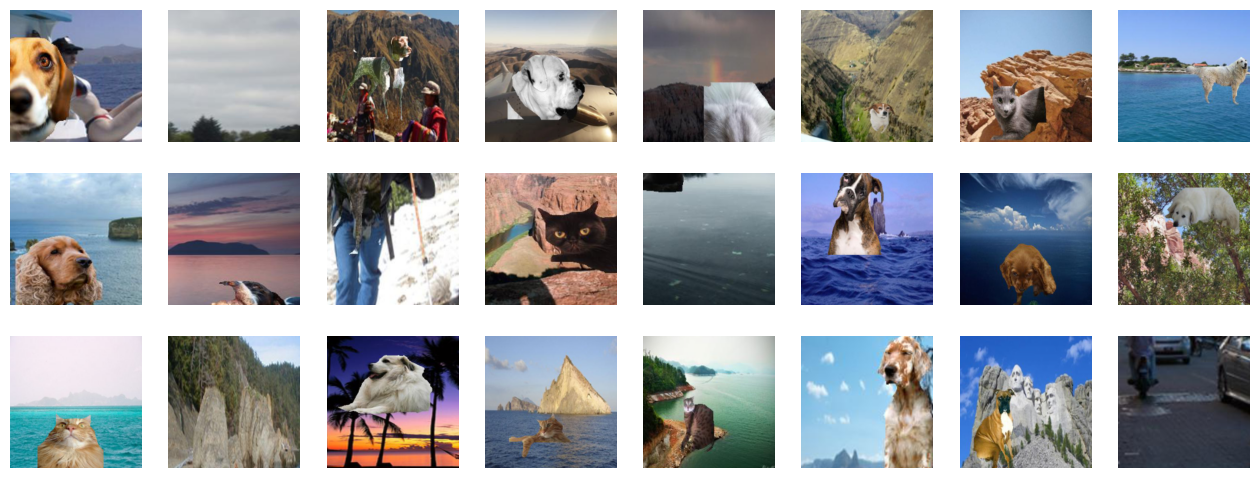

In [9]:
import matplotlib.pyplot as plt
import torch 
mean = torch.tensor((0.485, 0.456, 0.406)).reshape(1,1,3)
std = torch.tensor((0.229, 0.224, 0.225)).reshape(1,1,3)
def ten2im(dat):
    return dat.permute(1,2,0) * std + mean
    
fig, axes = plt.subplots(3,8,figsize=(16,6))
for i, data in enumerate(tr_loader):
    for j in range(8):
        axes[i,j].imshow(ten2im(data[0][j]))
        axes[i,j].axis('off')
    if i == 2:
        break
